## Load dataset

In [189]:
import os
import pandas as pd
import kagglehub
from sklearn.model_selection import train_test_split

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

In [190]:
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("CSV files:", csv_files)

CSV files: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [191]:
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [192]:
TARGET = "Churn"

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[TARGET]
)

print("Train:", train_df.shape)
print("Test :", test_df.shape)


print("\nOverall:")
print(df[TARGET].value_counts(normalize=True))

print("\nTrain:")
print(train_df[TARGET].value_counts(normalize=True))

print("\nTest:")
print(test_df[TARGET].value_counts(normalize=True))

Train: (5634, 21)
Test : (1409, 21)

Overall:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Train:
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

Test:
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [193]:
output_dir = "../data/raw"
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(
    os.path.join(output_dir, "train.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(output_dir, "test.csv"),
    index=False
)

In [194]:
print(df.dtypes)

categorical_cols = df.select_dtypes(include=["object", "category"]).columns

print("Categorical features:")
print(categorical_cols.tolist())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


## EDA & Preprocessing

In [195]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (5634, 20)
y_train: (5634,)
X_test : (1409, 20)
y_test : (1409,)


In [196]:
def get_feature_types(X):
    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numerical_features = X.select_dtypes(
        include=["number"]
    ).columns.tolist()

    print("\nCategorical features:")
    print(categorical_features)

    print("\nNumerical features:")
    print(numerical_features)

    return categorical_features, numerical_features

In [197]:
categorical_features, numerical_features = get_feature_types(X_train)


Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [198]:
X_train = X_train.drop(columns=["customerID"])
X_test = X_test.drop(columns=["customerID"])

In [199]:
X_train["TotalCharges"] = pd.to_numeric(
    X_train["TotalCharges"],
    errors="coerce"
)

X_test["TotalCharges"] = pd.to_numeric(
    X_test["TotalCharges"],
    errors="coerce"
)

In [200]:
print("Missing values:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Missing values:
TotalCharges    8
dtype: int64


In [201]:
median_total_charges = X_train["TotalCharges"].median()

X_train["TotalCharges"] = X_train["TotalCharges"].fillna(
    median_total_charges
)

X_test["TotalCharges"] = X_test["TotalCharges"].fillna(
    median_total_charges
)

In [202]:
categorical_features, numerical_features = get_feature_types(X_train)


Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


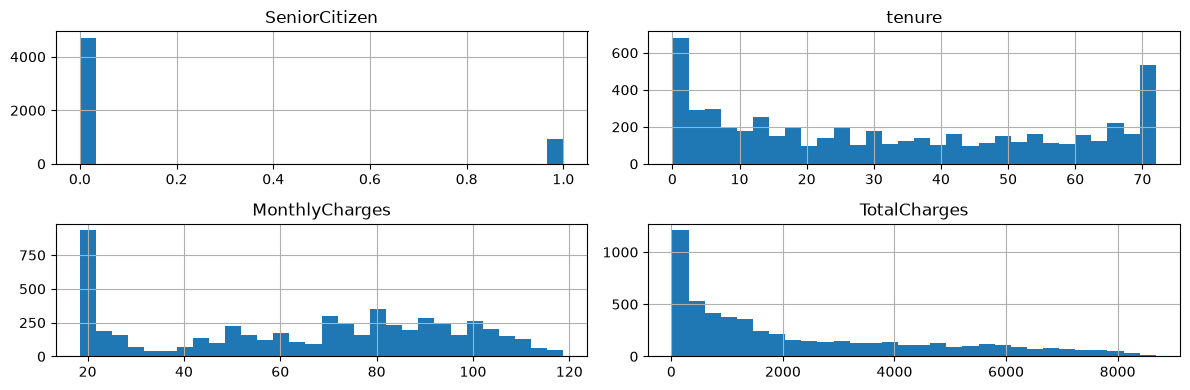

In [203]:
import matplotlib.pyplot as plt

X_train[numerical_features].hist(
    bins=30,
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

In [204]:
print(X_train[numerical_features].describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    5634.000000  5634.000000     5634.000000   5634.000000
mean        0.163294    32.485091       64.929961   2301.319950
std         0.369667    24.568744       30.138105   2277.808844
min         0.000000     0.000000       18.400000     18.850000
25%         0.000000     9.000000       35.662500    408.850000
50%         0.000000    29.000000       70.500000   1398.125000
75%         0.000000    55.000000       90.000000   3835.825000
max         1.000000    72.000000      118.750000   8684.800000


In [205]:
X_train["SeniorCitizen"] = X_train["SeniorCitizen"].astype("object")
X_test["SeniorCitizen"] = X_test["SeniorCitizen"].astype("object")

In [206]:
categorical_features, numerical_features = get_feature_types(X_train)


Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']


In [207]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_num = scaler.transform(
    X_test[numerical_features]
)

X_train_num = pd.DataFrame(
    X_train_num,
    columns=numerical_features,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    X_test_num,
    columns=numerical_features,
    index=X_test.index
)

X_train_num = pd.DataFrame(
    X_train_num,
    columns=numerical_features,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    X_test_num,
    columns=numerical_features,
    index=X_test.index
)

In [208]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_test.index
)

print("Categorical before:", X_train[categorical_features].shape)
print("Categorical after :", X_train_cat.shape)

Categorical before: (5634, 16)
Categorical after : (5634, 43)


In [209]:
X_train = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_test= pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)


print(X_train.shape)
print(X_test.shape)

(5634, 46)
(1409, 46)


In [210]:
y_train = y_train.map({
    "No": 0,
    "Yes": 1
})

y_test = y_test.map({
    "No": 0,
    "Yes": 1
})

## Evaluate Model Helper

In [211]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

print("\nTrain label ratio:")
print(y_train.value_counts(normalize=True))

print("\nValidation label ratio:")
print(y_val.value_counts(normalize=True))

Train: (4507, 46)
Validation: (1127, 46)

Train label ratio:
Churn
0    0.734635
1    0.265365
Name: proportion, dtype: float64

Validation label ratio:
Churn
0    0.734694
1    0.265306
Name: proportion, dtype: float64


In [212]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


results = []


def evaluate_model(
    model,
    X,
    y,
    dataset_name,
    model_name,
    params
):
    y_pred = model.predict(X)

    return {
        "Model": model_name,
        "Parameters": str(params),
        "Dataset": dataset_name,
        "Accuracy": round(accuracy_score(y, y_pred) * 100, 2),
        "Precision": round(
            precision_score(y, y_pred) * 100,
            2
        ),
        "Recall": round(
            recall_score(y, y_pred) * 100,
            2
        ),
        "F1": round(
            f1_score(y, y_pred) * 100,
            2
        )
    }

In [213]:
def print_result(model, model_name, params):
    global results

    results.append(
        evaluate_model(
            model,
            X_train,
            y_train,
            "Train",
            model_name,
            params
        )
    )

    results.append(
        evaluate_model(
            model,
            X_val,
            y_val,
            "Validation",
            model_name,
            params
        )
    )

    results.append(
        evaluate_model(
            model,
            X_test,
            y_test,
            "Test",
            model_name,
            params
        )
    )

    return pd.DataFrame(results)

In [214]:
from IPython.display import display, HTML
import pandas as pd


def display_results(df=None, model_name=None):
    if df is None:
        df = pd.DataFrame(results)

    display_df = df.copy()

    if model_name is not None:
        display_df = display_df[
            display_df["Model"] == model_name
        ].copy()

    if display_df.empty:
        print(f"No results found for model: {model_name}")
        return

    columns = display_df.columns.tolist()

    html = """
    <table style="
        border-collapse: collapse;
        width: 100%;
        text-align: center;
    ">
    <thead>
        <tr>
    """

    for col in columns:
        html += f"""
        <th style="
            border: 1px solid #ccc;
            padding: 6px;
        ">{col}</th>
        """

    html += "</tr></thead><tbody>"

    i = 0

    while i < len(display_df):

        row = display_df.iloc[i]

        j = i + 1

        while (
            j < len(display_df)
            and display_df.iloc[j]["Model"] == row["Model"]
            and display_df.iloc[j]["Parameters"] == row["Parameters"]
        ):
            j += 1

        rowspan = j - i

        for k in range(i, j):
            current_row = display_df.iloc[k]

            html += "<tr>"

            for col in columns:

                if col in ["Model", "Parameters"]:

                    if k == i:
                        html += f"""
                        <td rowspan="{rowspan}" style="
                            border: 1px solid #ccc;
                            padding: 6px;
                            vertical-align: middle;
                        ">
                            {current_row[col]}
                        </td>
                        """

                else:
                    html += f"""
                    <td style="
                        border: 1px solid #ccc;
                        padding: 6px;
                    ">
                        {current_row[col]}
                    </td>
                    """

            html += "</tr>"

        i = j

    html += "</tbody></table>"

    display(HTML(html))

In [215]:
global results
results.clear()

## Logistic Regression

In [216]:
from sklearn.linear_model import LogisticRegression

max_iters = [100, 500, 1000, 2000]
for max_iter in max_iters:

    params = {
        "max_iter": max_iter
    }

    model = LogisticRegression(
        max_iter=max_iter,
        random_state=42
    )

    model.fit(X_train, y_train)

    print_result(
        model,
        "LogisticRegression",
        params
    )

In [217]:
display_results(model_name="LogisticRegression")

## KNN

In [218]:
from sklearn.neighbors import KNeighborsClassifier

n_neighbors_list = [i for i in range(1, 21,2)]

for n_neighbors in n_neighbors_list:

    knn_model = KNeighborsClassifier(
        n_neighbors=n_neighbors
    )

    knn_model.fit(X_train, y_train)

    print_result(
        knn_model,
        model_name="KNN",
        params={
            "n_neighbors": n_neighbors
        }
    )

In [219]:
display_results(model_name="KNN")

## SVC

In [220]:
from sklearn.svm import SVC

kernels = ["linear", "rbf", "poly"]
C_values = [0.1, 1, 10]

for kernel in kernels:
    for C in C_values:

        svc_model = SVC(
            C=C,
            kernel=kernel,
            random_state=42
        )

        svc_model.fit(X_train, y_train)

        print_result(
            svc_model,
            model_name="SVC",
            params={
                "C": C,
                "kernel": kernel
            }
        )

In [221]:
display_results(model_name="SVC")

## Decision Tree

In [222]:
from sklearn.tree import DecisionTreeClassifier

max_depths = [3, 5, 7, 10, None]

for max_depth in max_depths:

    dt_model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=42
    )

    dt_model.fit(X_train, y_train)

    print_result(
        dt_model,
        model_name="DecisionTree",
        params={
            "max_depth": max_depth
        }
    )

In [223]:
display_results(model_name="DecisionTree")

## Random Forest

In [224]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [100, 200, 500]
max_depths = [5, 10, 15, None]

for n_estimators in n_estimators_list:
    for max_depth in max_depths:

        rf_model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        print_result(
            rf_model,
            model_name="RandomForest",
            params={
                "n_estimators": n_estimators,
                "max_depth": max_depth
            }
        )

In [225]:
display_results(model_name="RandomForest")

## XGboost

In [226]:
from xgboost import XGBClassifier

xgb_params = [
    {
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.1
    },
    {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.1
    },
    {
        "n_estimators": 200,
        "max_depth": 5,
        "learning_rate": 0.1
    },
    {
        "n_estimators": 200,
        "max_depth": 5,
        "learning_rate": 0.05
    }
]

for params in xgb_params:

    xgb_model = XGBClassifier(
        **params,
        random_state=42,
        eval_metric="logloss"
    )

    xgb_model.fit(X_train, y_train)

    print_result(
        xgb_model,
        model_name="XGBoost",
        params=params
    )

In [227]:
display_results(model_name="XGBoost")

In [228]:
def display_top_results(results_df, top_n=5, set="Validation"):
    validation_results = results_df[
        results_df["Dataset"] == set
    ].copy()

    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]

    validation_results["Score"] = (
        validation_results[metrics].mean(axis=1)
    )

    top_results = validation_results.sort_values(
        by="Score",
        ascending=False
    ).head(top_n)

    display(
        top_results.style
        .hide(axis="index")
        .format({
            "Accuracy": "{:.2f}",
            "Precision": "{:.2f}",
            "Recall": "{:.2f}",
            "F1": "{:.2f}",
            "Score": "{:.2f}"
        })
        .set_properties(**{
            "text-align": "center"
        })
    )

    return top_results

In [229]:
results_df = pd.DataFrame(results)
top_5 = display_top_results(results_df, top_n=5, set="Validation")

Model,Parameters,Dataset,Accuracy,Precision,Recall,F1,Score
LogisticRegression,{'max_iter': 100},Validation,81.63,69.66,54.52,61.16,66.74
LogisticRegression,{'max_iter': 1000},Validation,81.63,69.66,54.52,61.16,66.74
LogisticRegression,{'max_iter': 2000},Validation,81.63,69.66,54.52,61.16,66.74
LogisticRegression,{'max_iter': 500},Validation,81.63,69.66,54.52,61.16,66.74
SVC,"{'C': 0.1, 'kernel': 'linear'}",Validation,81.37,68.46,55.18,61.11,66.53


In [230]:
results_df = pd.DataFrame(results)
top_5 = display_top_results(results_df, top_n=5, set="Test")

Model,Parameters,Dataset,Accuracy,Precision,Recall,F1,Score
LogisticRegression,{'max_iter': 100},Test,79.91,64.44,54.28,58.93,64.39
LogisticRegression,{'max_iter': 500},Test,79.91,64.44,54.28,58.93,64.39
LogisticRegression,{'max_iter': 1000},Test,79.91,64.44,54.28,58.93,64.39
LogisticRegression,{'max_iter': 2000},Test,79.91,64.44,54.28,58.93,64.39
XGBoost,"{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}",Test,80.20,65.99,52.41,58.42,64.25
